In [5]:
import sys, os
sys.path.append('../')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from corr_coeff_functions import build_corr_coeff_2D, build_rankdata_2D
from geometry import L2_distance, build_get_similarities, build_information_imbalance

master_key = jax.random.PRNGKey(12345)
key_w1, key_w2, key_x, key_eps, key_distances = jax.random.split(master_key, 5)
key_distances, subkey_distances = jax.random.split(key_distances)

Ns = 2500
D = 10
r = 4
noise_scales = np.linspace(0.0, 5.0, 5)

# Build a rank-r linear map W in R^{D x D}.
left = jax.random.normal(key_w1, (D, r))
right = jax.random.normal(key_w2, (r, D))
W = left @ right

X = jax.random.normal(key_x, (Ns, D))
signal = X @ W.T
base_epsilon = jax.random.normal(key_eps, (Ns, D))

get_l2_similarities = build_get_similarities(
    key=subkey_distances,
    sample_size=Ns,
    similarity_fn=L2_distance,
)
rankdata_2D = build_rankdata_2D()
xi_fn = build_corr_coeff_2D(average=False)
II_fn = build_information_imbalance(k=1)

def get_Y(noise_scale):
    return signal + noise_scale * base_epsilon

def get_l2_matrices(noise_scale):
    Y = get_Y(noise_scale)
    return get_l2_similarities(X, Y)


In [6]:
ii_xy = []
ii_yx = []
xi_xy_all = []
xi_yx_all = []
xi_xy = []
xi_yx = []
xi_xy_std = []
xi_yx_std = []
ranks_x_first = None
ranks_y_first = None

for idx, noise_scale in enumerate(noise_scales):
    sim_X, sim_Y = get_l2_matrices(float(noise_scale))

    # II computation
    ranks_x = rankdata_2D(sim_X)
    ranks_y = rankdata_2D(sim_Y)
    ii_values, _ = II_fn(ranks_x, ranks_y)
    ii_xy.append(float(np.array(ii_values)[0]))
    ii_yx.append(float(np.array(ii_values)[1]))

    # xi computation
    if idx == 0:
        ranks_x_first = np.array(ranks_x)
        ranks_y_first = np.array(ranks_y)
    xi_xy_values, xi_yx_values = xi_fn((ranks_x, ranks_y))
    xi_xy_values = np.array(xi_xy_values)
    xi_yx_values = np.array(xi_yx_values)
    xi_xy_all.append(xi_xy_values)
    xi_yx_all.append(xi_yx_values)
    xi_xy.append(float(xi_xy_values.mean()))
    xi_yx.append(float(xi_yx_values.mean()))
    xi_xy_std.append(float(xi_xy_values.std()))
    xi_yx_std.append(float(xi_yx_values.std()))

ii_xy = np.array(ii_xy)
ii_yx = np.array(ii_yx)
xi_xy_all = np.stack(xi_xy_all)
xi_yx_all = np.stack(xi_yx_all)
xi_xy = np.array(xi_xy)
xi_yx = np.array(xi_yx)
xi_xy_std = np.array(xi_xy_std)
xi_yx_std = np.array(xi_yx_std)


/tmp/ipykernel_3660296/2620404585.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


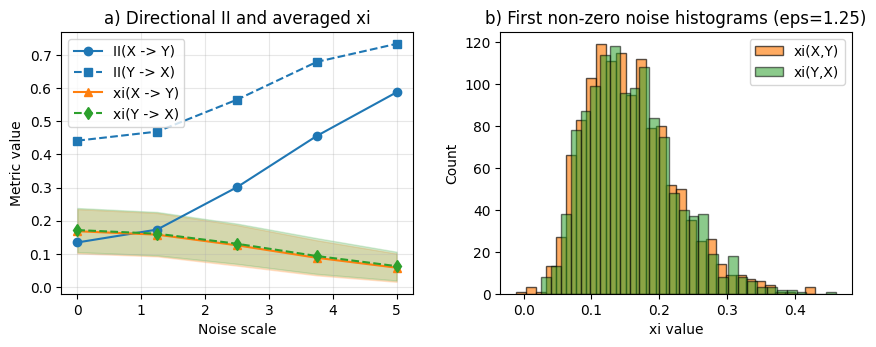

In [7]:
# Panel a): directional II and averaged xi vs noise.
# Panel b): pointwise xi distributions at the first non-zero noise scale.
noise_idx_first = int(np.where(noise_scales > 0.0)[0][0])
noise_first = float(noise_scales[noise_idx_first])
xi_xy_first = xi_xy_all[noise_idx_first]
xi_yx_first = xi_yx_all[noise_idx_first]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.4), gridspec_kw={'wspace': 0.25})

ii_color = 'tab:blue'
color_xy = 'tab:orange'
color_yx = 'tab:green'
axes[0].plot(noise_scales, ii_xy, marker='o', color=ii_color, label='II(X -> Y)')
axes[0].plot(noise_scales, ii_yx, marker='s', linestyle='--', color=ii_color, label='II(Y -> X)')
axes[0].plot(noise_scales, xi_xy, marker='^', color=color_xy, label='xi(X -> Y)')
axes[0].fill_between(noise_scales, xi_xy - xi_xy_std, xi_xy + xi_xy_std, color=color_xy, alpha=0.2)
axes[0].plot(noise_scales, xi_yx, marker='d', linestyle='--', color=color_yx, label='xi(Y -> X)')
axes[0].fill_between(noise_scales, xi_yx - xi_yx_std, xi_yx + xi_yx_std, color=color_yx, alpha=0.2)
axes[0].set_xlabel('Noise scale')
axes[0].set_ylabel('Metric value')
axes[0].set_title('a) Directional II and averaged xi')
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

bins = 30
axes[1].hist(xi_xy_first, bins=bins, color=color_xy, alpha=0.65, edgecolor='black', label='xi(X,Y)')
axes[1].hist(xi_yx_first, bins=bins, color=color_yx, alpha=0.55, edgecolor='black', label='xi(Y,X)')
axes[1].set_title(f'b) First non-zero noise histograms (eps={noise_first:.2f})')
axes[1].set_xlabel('xi value')
axes[1].set_ylabel('Count')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


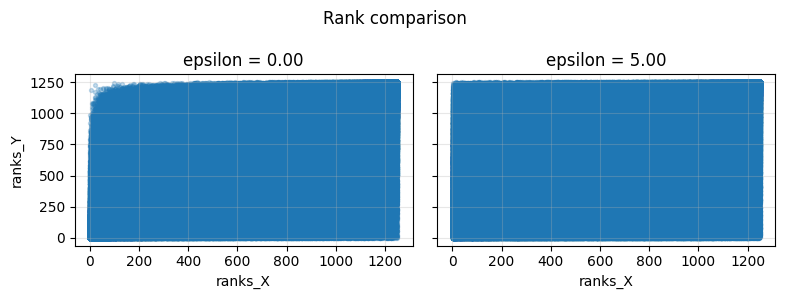

In [8]:
noise_scale_ref = float(noise_scales[-1])
sim_X_ref, sim_Y_ref = get_l2_matrices(noise_scale_ref)
ranks_x_ref = np.array(rankdata_2D(sim_X_ref))
ranks_y_ref = np.array(rankdata_2D(sim_Y_ref))

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

axes[0].scatter(ranks_x_first.ravel(), ranks_y_first.ravel(), s=8, alpha=0.25)
axes[0].set_xlabel('ranks_X')
axes[0].set_ylabel('ranks_Y')
axes[0].set_title(f'epsilon = {noise_scales[0]:.2f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(ranks_x_ref.ravel(), ranks_y_ref.ravel(), s=8, alpha=0.25)
axes[1].set_xlabel('ranks_X')
axes[1].set_title(f'epsilon = {noise_scale_ref:.2f}')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Rank comparison')
plt.tight_layout()
plt.show()
